# Debutanizer Soft Sensor — Week 1: EDA & PLS Baseline

**Goal:** Establish a baseline soft sensor for butane (C4) concentration in the bottom flow of a debutanizer column, using 7 process measurements (temperatures, pressures, flows).

**Data:** Fortuna et al. (2007), 2,394 samples, pre-normalized.

**Split:** Chronological 70/15/15 (train/val/test) — no shuffling.

## Results

| Model | Features | Val RMSE | Test RMSE | Test R² |
|-------|----------|----------|-----------|---------|
| PLS (n=3) | Raw u1–u7 | 0.155 | 0.184 | 0.05 |
| PLS (n=11) | Raw + lags [1,2,3,5,7,10] | **0.102** | **0.172** | **0.17** |

## Key findings

1. **Lagged features dominate model choice.** Adding 6 lags per input lifted val R² from 0.16 to 0.64 — without changing the model class. Process dynamics matter more than model complexity at this stage.
2. **Distribution shift on test.** The chronological test set contains low-y operating conditions barely seen in training (test min 0.000 vs train min 0.019). Linear PLS reverts to the train mean in this regime, producing systematic +0.25 overprediction.
3. **Multicollinearity confirmed:** u6 and u7 (two bottom temperature sensors) correlate at 0.99. PLS handles this natively.

## Next (Week 2)

- XGBoost and 1D-CNN models — can nonlinearity close the test gap?
- TimeSeriesSplit cross-validation in place of single val split.
- SHAP feature importance to interpret which lags matter most.

In [27]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display config
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid", context="notebook")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports loaded. Pandas:", pd.__version__, "| NumPy:", np.__version__)

Imports loaded. Pandas: 3.0.3 | NumPy: 2.4.5


In [28]:
# Path to raw data — relative to the notebook location
DATA_PATH = "../data/raw/Debutanizer_Data.txt"

# File is whitespace-separated with a header row
df = pd.read_csv(DATA_PATH, sep=r'\s+')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (2394, 8)
Columns: ['u1', 'u2', 'u3', 'u4', 'u5', 'u6', 'u7', 'y']


,u1,u2,u3,u4,u5,u6,u7,y
0,0.268900,0.650894,0.832742,0.583420,0.784759,0.843079,0.822079,0.180295
1,0.268483,0.650140,0.852153,0.577510,0.776487,0.838605,0.822079,0.177124
2,0.267967,0.659657,0.823618,0.571600,0.764546,0.807879,0.786246,0.173618
3,0.267451,0.668338,0.808371,0.565689,0.752605,0.799606,0.786246,0.171640
4,0.266935,0.647191,0.761948,0.559779,0.745326,0.773122,0.746142,0.166972


In [29]:
# Data types, missing values, basic stats
print("=== Data types ===")
print(df.dtypes)
print("\n=== Missing values per column ===")
print(df.isnull().sum())
print("\n=== Summary statistics ===")
df.describe()

=== Data types ===
u1    float64
u2    float64
u3    float64
u4    float64
u5    float64
u6    float64
u7    float64
y     float64
dtype: object

=== Missing values per column ===
u1    0
u2    0
u3    0
u4    0
u5    0
u6    0
u7    0
y     0
dtype: int64

=== Summary statistics ===


,u1,u2,u3,u4,u5,u6,u7,y
count,2394.000000,2394.000000,2394.000000,2394.000000,2394.000000,2394.000000,2394.000000,2394.000000
mean,0.283894,0.667847,0.598467,0.435948,0.658086,0.620741,0.589397,0.267788
std,0.103143,0.057690,0.198581,0.138237,0.127054,0.165116,0.173251,0.158943
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.224004,0.653819,0.500390,0.363369,0.608661,0.481804,0.445001,0.169188
50%,0.263995,0.671915,0.624269,0.396288,0.694644,0.639585,0.600959,0.246857
75%,0.325607,0.690943,0.742784,0.518144,0.730119,0.755050,0.741387,0.318061
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


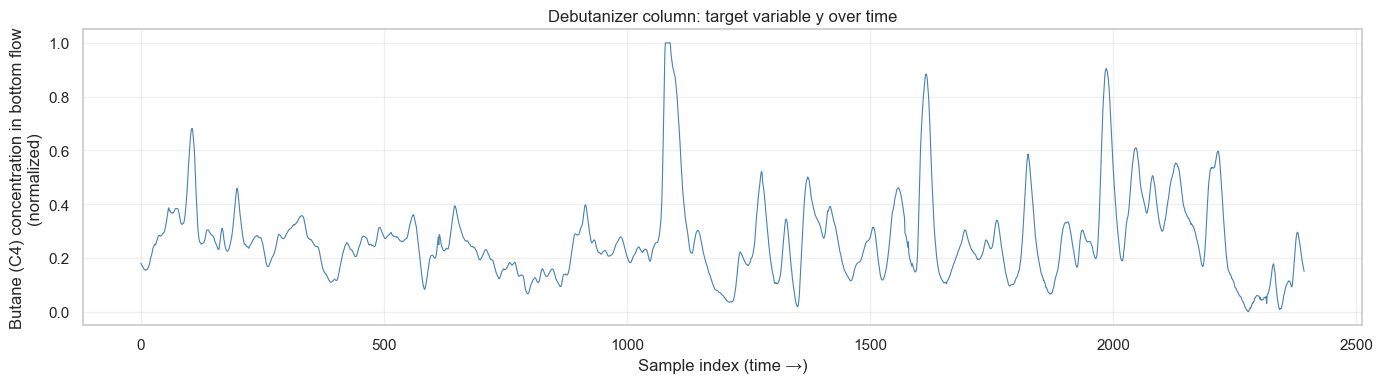

y range: [0.000, 1.000]
y mean: 0.268, std: 0.159


In [30]:
# Time series plot of the target variable
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['y'], linewidth=0.8, color='steelblue')
ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("Butane (C4) concentration in bottom flow\n(normalized)")
ax.set_title("Debutanizer column: target variable y over time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"y range: [{df['y'].min():.3f}, {df['y'].max():.3f}]")
print(f"y mean: {df['y'].mean():.3f}, std: {df['y'].std():.3f}")

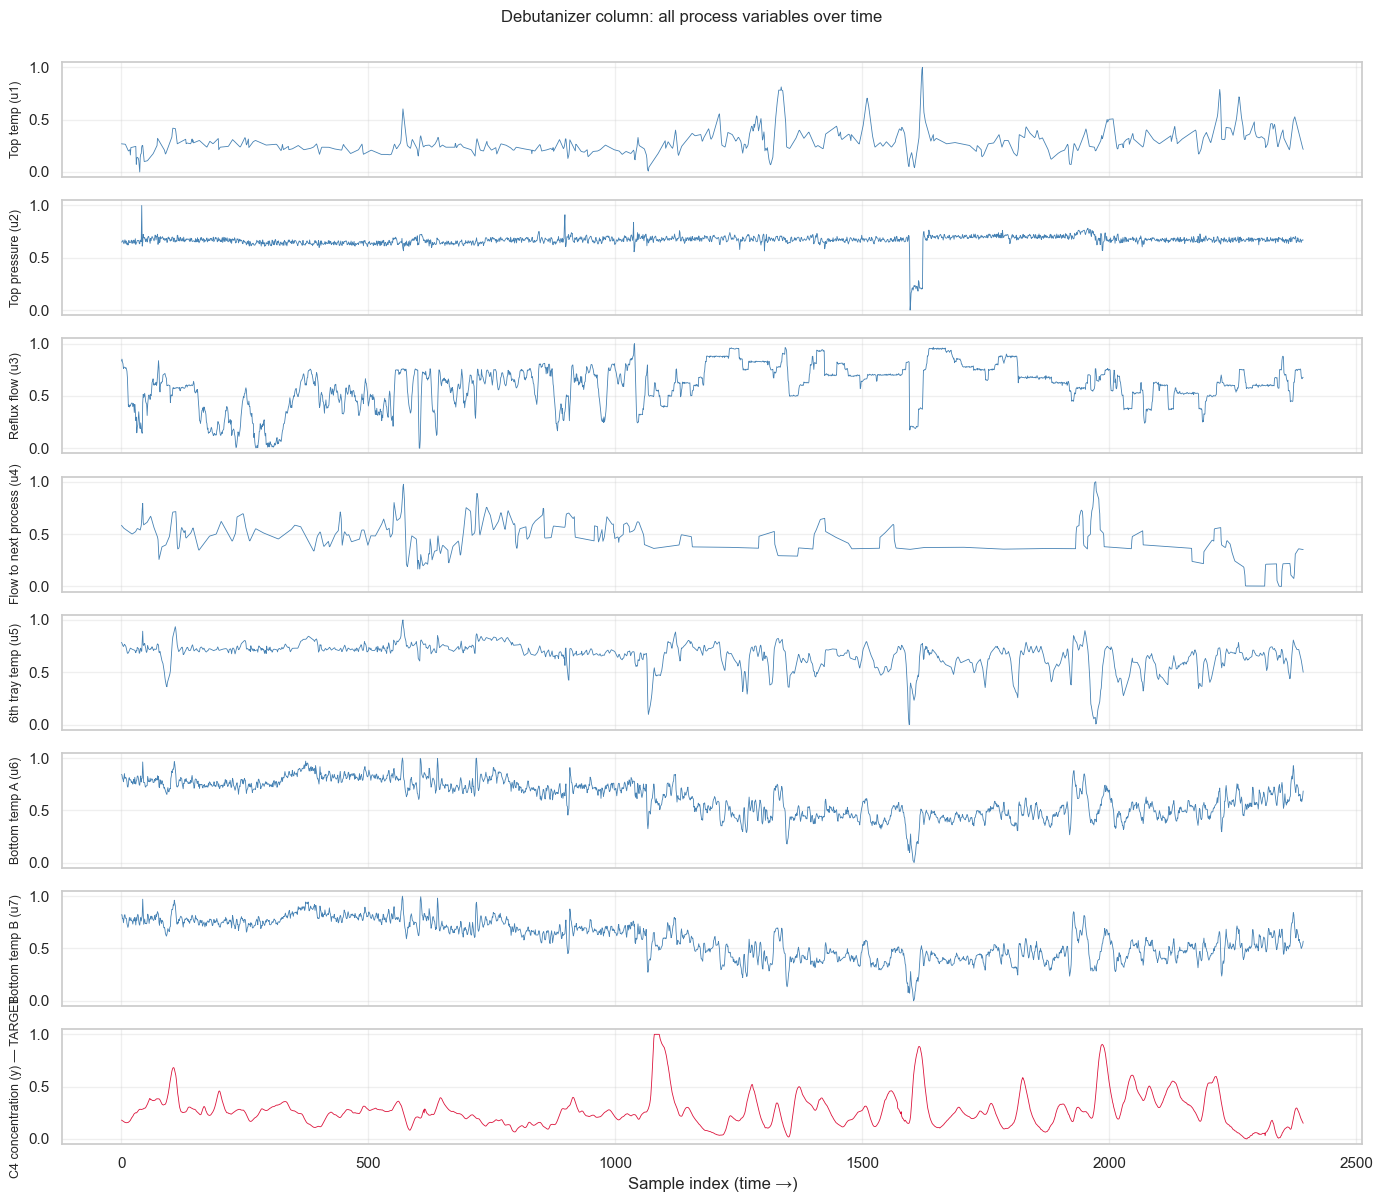

In [31]:
# Plot all 7 inputs + target on a stacked grid to see relationships
fig, axes = plt.subplots(8, 1, figsize=(14, 12), sharex=True)
cols = ['u1', 'u2', 'u3', 'u4', 'u5', 'u6', 'u7', 'y']
labels = ['Top temp (u1)', 'Top pressure (u2)', 'Reflux flow (u3)',
          'Flow to next process (u4)', '6th tray temp (u5)',
          'Bottom temp A (u6)', 'Bottom temp B (u7)', 'C4 concentration (y) — TARGET']

for ax, col, label in zip(axes, cols, labels):
    color = 'crimson' if col == 'y' else 'steelblue'
    ax.plot(df.index, df[col], linewidth=0.6, color=color)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Sample index (time →)")
fig.suptitle("Debutanizer column: all process variables over time", y=1.00, fontsize=12)
plt.tight_layout()
plt.show()

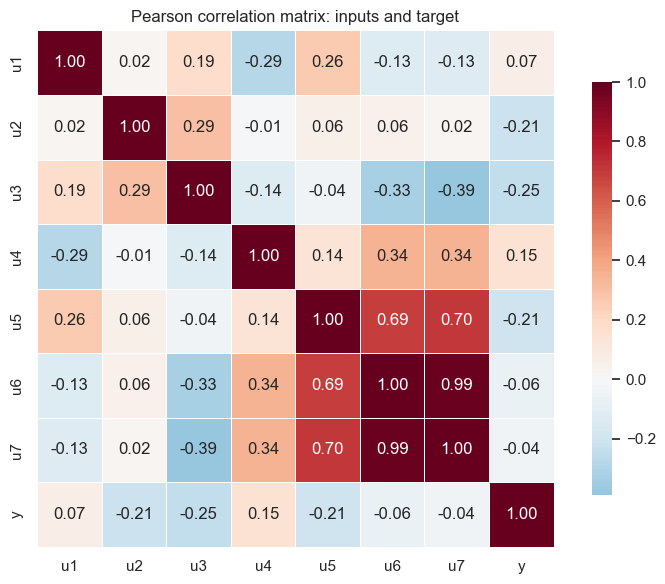


Correlation of each input with target y (sorted):
u3   -0.248085
u2   -0.210909
u5   -0.210236
u4    0.149349
u1    0.068679
u6   -0.064930
u7   -0.043576
Name: y, dtype: float64


In [32]:
# Correlation matrix
corr = df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson correlation matrix: inputs and target")
plt.tight_layout()
plt.show()

# Sorted correlations with target
print("\nCorrelation of each input with target y (sorted):")
print(corr['y'].drop('y').sort_values(key=abs, ascending=False))

In [33]:
# Chronological train/validation/test split — NO SHUFFLING
n = len(df)
train_end = int(n * 0.70)   # samples 0 .. 1675
val_end   = int(n * 0.85)   # samples 1676 .. 2034
                            # samples 2035 .. 2393 = test

X_cols = ['u1', 'u2', 'u3', 'u4', 'u5', 'u6', 'u7']
y_col  = 'y'

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Train:      {len(train_df):4d} samples  (index    0 .. {train_end-1})")
print(f"Validation: {len(val_df):4d} samples  (index {train_end} .. {val_end-1})")
print(f"Test:       {len(test_df):4d} samples  (index {val_end} .. {n-1})")
print(f"Total:      {len(train_df)+len(val_df)+len(test_df)} (should equal {n})")

Train:      1675 samples  (index    0 .. 1674)
Validation:  359 samples  (index 1675 .. 2033)
Test:        360 samples  (index 2034 .. 2393)
Total:      2394 (should equal 2394)


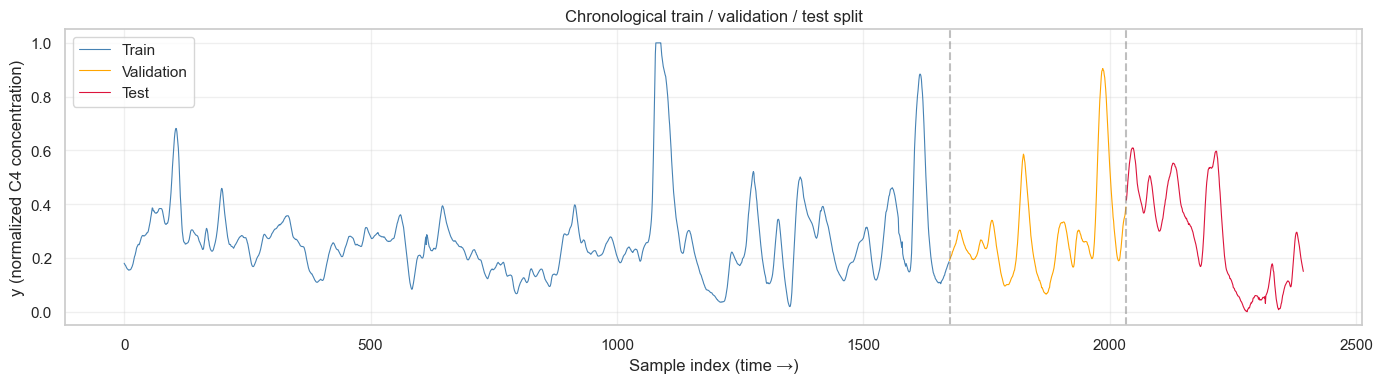

In [34]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df.index, train_df['y'], color='steelblue', linewidth=0.8, label='Train')
ax.plot(val_df.index,   val_df['y'],   color='orange',    linewidth=0.8, label='Validation')
ax.plot(test_df.index,  test_df['y'],  color='crimson',   linewidth=0.8, label='Test')
ax.axvline(train_end, color='gray', linestyle='--', alpha=0.5)
ax.axvline(val_end,   color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("y (normalized C4 concentration)")
ax.set_title("Chronological train / validation / test split")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Distribution check — if train and test differ wildly, you have non-stationarity
summary = pd.DataFrame({
    'train': train_df[y_col].describe(),
    'val':   val_df[y_col].describe(),
    'test':  test_df[y_col].describe(),
})
print(summary.round(3))

          train      val     test
count  1675.000  359.000  360.000
mean      0.263    0.282    0.275
std       0.149    0.170    0.189
min       0.019    0.065    0.000
25%       0.176    0.193    0.089
50%       0.244    0.247    0.283
75%       0.300    0.312    0.443
max       1.000    0.904    0.609


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train only — this is critical
X_train = scaler.fit_transform(train_df[X_cols])
X_val   = scaler.transform(val_df[X_cols])
X_test  = scaler.transform(test_df[X_cols])

y_train = train_df[y_col].values
y_val   = val_df[y_col].values
y_test  = test_df[y_col].values

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

# Sanity check: train means should be ~0, stds should be ~1
print(f"\nX_train column means (should be ~0): {X_train.mean(axis=0).round(3)}")
print(f"X_train column stds  (should be ~1): {X_train.std(axis=0).round(3)}")

X_train shape: (1675, 7), y_train shape: (1675,)
X_val shape:   (359, 7), y_val shape:   (359,)
X_test shape:  (360, 7), y_test shape:  (360,)

X_train column means (should be ~0): [ 0.  0.  0. -0. -0. -0. -0.]
X_train column stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


In [37]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []
for n in range(1, 8):
    pls = PLSRegression(n_components=n)
    pls.fit(X_train, y_train)

    y_pred_train = pls.predict(X_train).ravel()
    y_pred_val   = pls.predict(X_val).ravel()

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    val_rmse   = np.sqrt(mean_squared_error(y_val,   y_pred_val))
    val_r2     = r2_score(y_val, y_pred_val)

    results.append({
        'n_components': n,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'val_r2': val_r2
    })

results_df = pd.DataFrame(results)
print(results_df.round(4))

best_n = int(results_df.loc[results_df['val_rmse'].idxmin(), 'n_components'])
print(f"\nBest n_components by validation RMSE: {best_n}")

   n_components  train_rmse  val_rmse  val_r2
0             1      0.1384    0.1695  0.0051
1             2      0.1368    0.1656  0.0503
2             3      0.1351    0.1553  0.1647
3             4      0.1339    0.1579  0.1361
4             5      0.1336    0.1574  0.1422
5             6      0.1336    0.1572  0.1439
6             7      0.1334    0.1563  0.1538

Best n_components by validation RMSE: 3


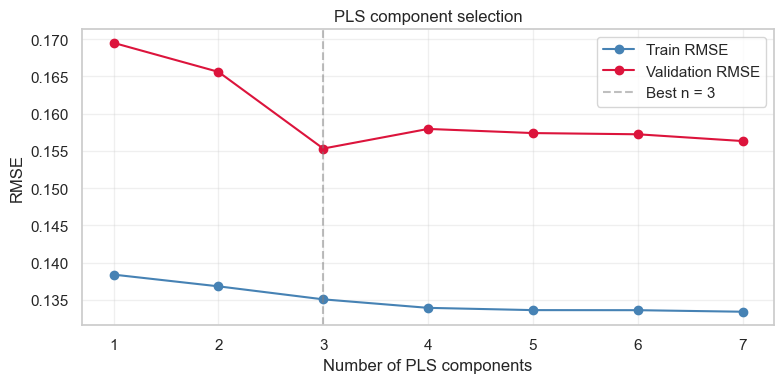

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['n_components'], results_df['train_rmse'], 'o-', label='Train RMSE', color='steelblue')
ax.plot(results_df['n_components'], results_df['val_rmse'],   'o-', label='Validation RMSE', color='crimson')
ax.axvline(best_n, color='gray', linestyle='--', alpha=0.5, label=f'Best n = {best_n}')
ax.set_xlabel("Number of PLS components")
ax.set_ylabel("RMSE")
ax.set_title("PLS component selection")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Final PLS model with chosen n
pls_final = PLSRegression(n_components=best_n)
pls_final.fit(X_train, y_train)

# Predictions
y_pred_train = pls_final.predict(X_train).ravel()
y_pred_val   = pls_final.predict(X_val).ravel()
y_pred_test  = pls_final.predict(X_test).ravel()

# Metrics function
def metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'split': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

metrics_df = pd.DataFrame([
    metrics(y_train, y_pred_train, 'train'),
    metrics(y_val,   y_pred_val,   'val'),
    metrics(y_test,  y_pred_test,  'test'),
])
print(metrics_df.round(4))

   split    RMSE     MAE      R2
0  train  0.1351  0.0896  0.1781
1    val  0.1553  0.1040  0.1647
2   test  0.1840  0.1583  0.0464


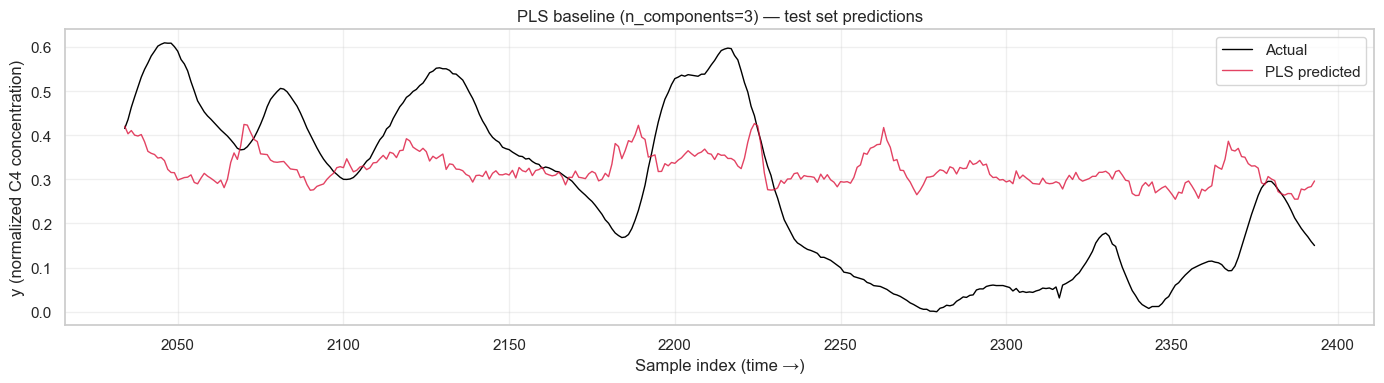

In [40]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_df.index, y_test,      label='Actual', color='black', linewidth=1.0)
ax.plot(test_df.index, y_pred_test, label='PLS predicted', color='crimson', linewidth=1.0, alpha=0.8)
ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("y (normalized C4 concentration)")
ax.set_title(f"PLS baseline (n_components={best_n}) — test set predictions")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

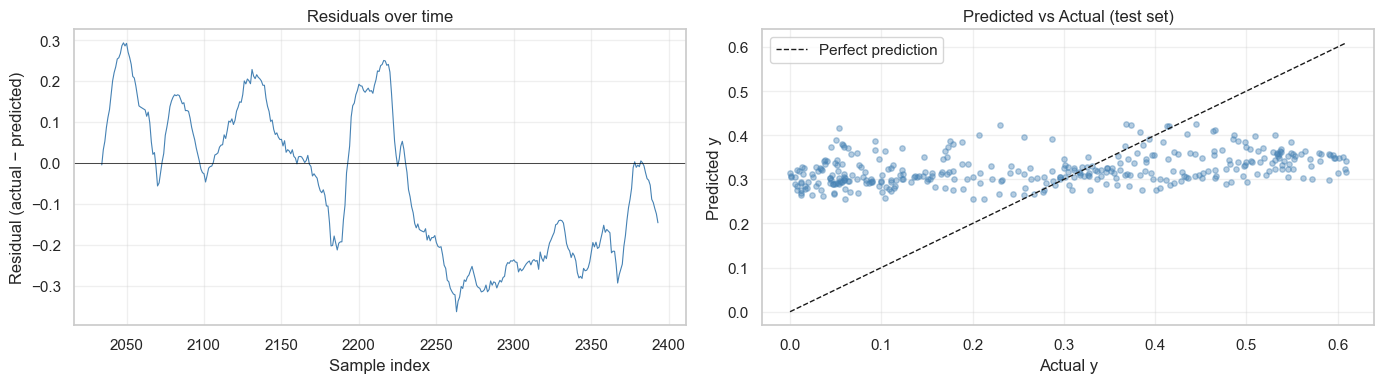

Residual mean: -0.0479 (should be near 0 if unbiased)
Residual std:  0.1777


In [41]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals over time
axes[0].plot(test_df.index, residuals, color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals over time")
axes[0].grid(True, alpha=0.3)

# Predicted vs actual scatter
axes[1].scatter(y_test, y_pred_test, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel("Actual y")
axes[1].set_ylabel("Predicted y")
axes[1].set_title("Predicted vs Actual (test set)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f} (should be near 0 if unbiased)")
print(f"Residual std:  {residuals.std():.4f}")

In [42]:
import json
from pathlib import Path

results_dir = Path("../docs")
results_dir.mkdir(exist_ok=True)

baseline_results = {
    "model": "PLS",
    "features": "raw u1-u7, no lags",
    "n_components": int(best_n),
    "train_rmse": float(np.sqrt(mean_squared_error(y_train, y_pred_train))),
    "val_rmse":   float(np.sqrt(mean_squared_error(y_val,   y_pred_val))),
    "test_rmse":  float(np.sqrt(mean_squared_error(y_test,  y_pred_test))),
    "train_r2":   float(r2_score(y_train, y_pred_train)),
    "val_r2":     float(r2_score(y_val,   y_pred_val)),
    "test_r2":    float(r2_score(y_test,  y_pred_test)),
}

with open(results_dir / "baseline_pls_raw.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Saved baseline results to docs/baseline_pls_raw.json:")
print(json.dumps(baseline_results, indent=2))

Saved baseline results to docs/baseline_pls_raw.json:
{
  "model": "PLS",
  "features": "raw u1-u7, no lags",
  "n_components": 3,
  "train_rmse": 0.13506881562166548,
  "val_rmse": 0.15530106405738617,
  "test_rmse": 0.1840074913902606,
  "train_r2": 0.17813820311359552,
  "val_r2": 0.16467119611226444,
  "test_r2": 0.04642958027225452
}


In [43]:
# Build a feature matrix with lagged copies of each input
LAGS = [1, 2, 3, 5, 7, 10]   # samples back to look — covers ~10 timesteps of history

def add_lags(df, cols, lags):
    """Return a new dataframe with original columns plus their lagged versions."""
    out = df.copy()
    for col in cols:
        for lag in lags:
            out[f"{col}_lag{lag}"] = out[col].shift(lag)
    return out

df_lagged = add_lags(df, X_cols, LAGS)

# Drop rows where any lag is NaN (the first max(LAGS) rows)
df_lagged = df_lagged.dropna().reset_index(drop=True)

print(f"Original shape: {df.shape}")
print(f"Lagged shape:   {df_lagged.shape}")
print(f"New feature count: {len([c for c in df_lagged.columns if c != 'y'])}")
print(f"First 3 column names: {df_lagged.columns.tolist()[:3]}")
print(f"Last 3 column names:  {df_lagged.columns.tolist()[-3:]}")

Original shape: (2394, 8)
Lagged shape:   (2384, 50)
New feature count: 49
First 3 column names: ['u1', 'u2', 'u3']
Last 3 column names:  ['u7_lag5', 'u7_lag7', 'u7_lag10']


In [44]:
# Define feature column list — everything except y
X_cols_lagged = [c for c in df_lagged.columns if c != 'y']

n2 = len(df_lagged)
train_end2 = int(n2 * 0.70)
val_end2   = int(n2 * 0.85)

train2 = df_lagged.iloc[:train_end2]
val2   = df_lagged.iloc[train_end2:val_end2]
test2  = df_lagged.iloc[val_end2:]

# Rescale with the new feature set
scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(train2[X_cols_lagged])
X_val2   = scaler2.transform(val2[X_cols_lagged])
X_test2  = scaler2.transform(test2[X_cols_lagged])

y_train2 = train2['y'].values
y_val2   = val2['y'].values
y_test2  = test2['y'].values

print(f"Train: {X_train2.shape}, Val: {X_val2.shape}, Test: {X_test2.shape}")

Train: (1668, 49), Val: (358, 49), Test: (358, 49)


In [45]:
results_lagged = []
for n in range(1, 21):   # more components allowed; we have 49 features now
    pls = PLSRegression(n_components=n)
    pls.fit(X_train2, y_train2)
    train_rmse = np.sqrt(mean_squared_error(y_train2, pls.predict(X_train2).ravel()))
    val_rmse   = np.sqrt(mean_squared_error(y_val2,   pls.predict(X_val2).ravel()))
    results_lagged.append({'n_components': n, 'train_rmse': train_rmse, 'val_rmse': val_rmse})

results_lagged_df = pd.DataFrame(results_lagged)
print(results_lagged_df.round(4))

best_n_lagged = int(results_lagged_df.loc[results_lagged_df['val_rmse'].idxmin(), 'n_components'])
print(f"\nBest n_components with lagged features: {best_n_lagged}")

    n_components  train_rmse  val_rmse
0              1      0.1219    0.1569
1              2      0.1153    0.1432
2              3      0.1020    0.1116
3              4      0.0984    0.1227
4              5      0.0941    0.1137
5              6      0.0926    0.1157
6              7      0.0903    0.1095
7              8      0.0889    0.1058
8              9      0.0879    0.1033
9             10      0.0875    0.1023
10            11      0.0874    0.1018
11            12      0.0873    0.1014
12            13      0.0872    0.1012
13            14      0.0872    0.1016
14            15      0.0872    0.1011
15            16      0.0872    0.1011
16            17      0.0872    0.1013
17            18      0.0872    0.1012
18            19      0.0872    0.1012
19            20      0.0871    0.1011

Best n_components with lagged features: 15


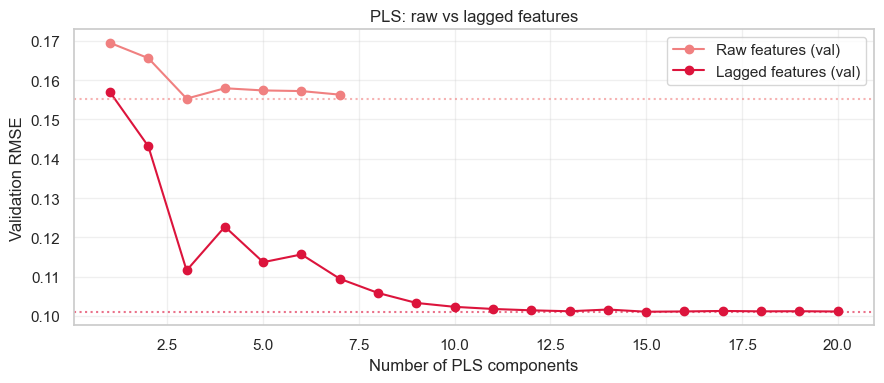

In [46]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(results_df['n_components'], results_df['val_rmse'], 'o-', label='Raw features (val)', color='lightcoral')
ax.plot(results_lagged_df['n_components'], results_lagged_df['val_rmse'], 'o-', label='Lagged features (val)', color='crimson')
ax.axhline(results_df['val_rmse'].min(), color='lightcoral', linestyle=':', alpha=0.6)
ax.axhline(results_lagged_df['val_rmse'].min(), color='crimson', linestyle=':', alpha=0.6)
ax.set_xlabel("Number of PLS components")
ax.set_ylabel("Validation RMSE")
ax.set_title("PLS: raw vs lagged features")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Final lagged PLS model — prefer n=11 for parsimony
N_LAGGED = 11

pls_lagged = PLSRegression(n_components=N_LAGGED)
pls_lagged.fit(X_train2, y_train2)

y_pred_train2 = pls_lagged.predict(X_train2).ravel()
y_pred_val2   = pls_lagged.predict(X_val2).ravel()
y_pred_test2  = pls_lagged.predict(X_test2).ravel()

metrics_lagged = pd.DataFrame([
    metrics(y_train2, y_pred_train2, 'train'),
    metrics(y_val2,   y_pred_val2,   'val'),
    metrics(y_test2,  y_pred_test2,  'test'),
])
print("=== Lagged PLS (n_components=11) ===")
print(metrics_lagged.round(4))

print("\n=== Raw PLS for comparison ===")
print(metrics_df.round(4))

=== Lagged PLS (n_components=11) ===
   split    RMSE     MAE      R2
0  train  0.0874  0.0613  0.6567
1    val  0.1018  0.0781  0.6429
2   test  0.1715  0.1398  0.1730

=== Raw PLS for comparison ===
   split    RMSE     MAE      R2
0  train  0.1351  0.0896  0.1781
1    val  0.1553  0.1040  0.1647
2   test  0.1840  0.1583  0.0464


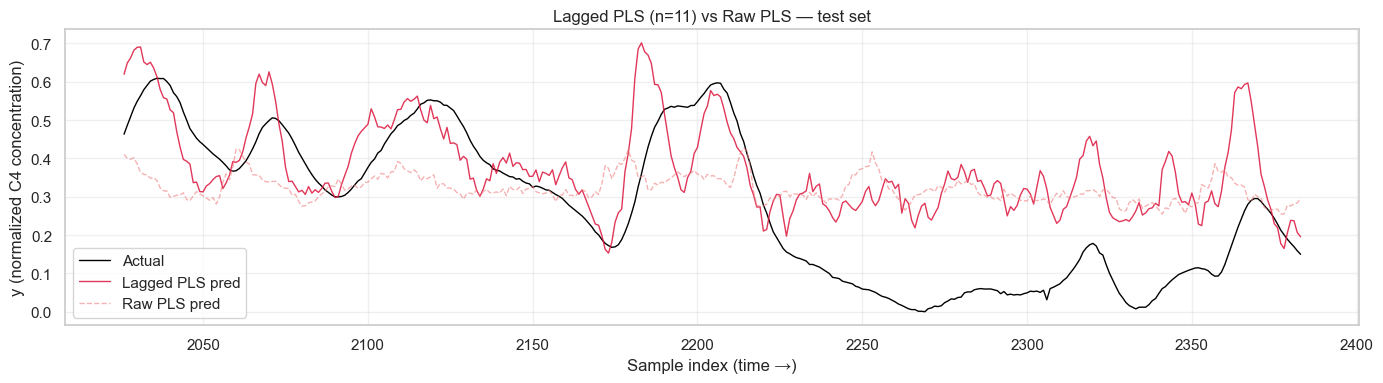

In [48]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test2.index, y_test2,        label='Actual',           color='black',    linewidth=1.0)
ax.plot(test2.index, y_pred_test2,   label='Lagged PLS pred',  color='crimson',  linewidth=1.0, alpha=0.85)
ax.plot(test2.index, y_pred_test[-len(test2):] if len(y_pred_test) >= len(test2) else y_pred_test,
        label='Raw PLS pred',     color='lightcoral', linewidth=1.0, alpha=0.6, linestyle='--')
ax.set_xlabel("Sample index (time →)")
ax.set_ylabel("y (normalized C4 concentration)")
ax.set_title(f"Lagged PLS (n={N_LAGGED}) vs Raw PLS — test set")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

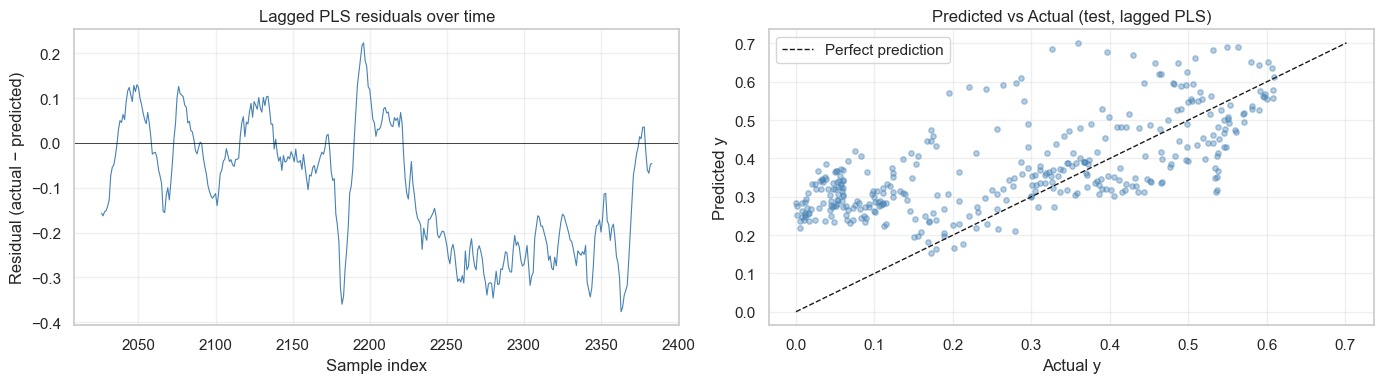

Residual mean: -0.1010
Residual std:  0.1387


In [49]:
residuals2 = y_test2 - y_pred_test2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test2.index, residuals2, color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Lagged PLS residuals over time")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test2, y_pred_test2, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test2.min(), y_pred_test2.min()), max(y_test2.max(), y_pred_test2.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel("Actual y")
axes[1].set_ylabel("Predicted y")
axes[1].set_title("Predicted vs Actual (test, lagged PLS)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals2.mean():.4f}")
print(f"Residual std:  {residuals2.std():.4f}")

In [50]:
baseline_results_lagged = {
    "model": "PLS",
    "features": f"lagged u1-u7 (lags {LAGS})",
    "n_components": N_LAGGED,
    "n_features": len(X_cols_lagged),
    "train_rmse": float(np.sqrt(mean_squared_error(y_train2, y_pred_train2))),
    "val_rmse":   float(np.sqrt(mean_squared_error(y_val2,   y_pred_val2))),
    "test_rmse":  float(np.sqrt(mean_squared_error(y_test2,  y_pred_test2))),
    "train_r2":   float(r2_score(y_train2, y_pred_train2)),
    "val_r2":     float(r2_score(y_val2,   y_pred_val2)),
    "test_r2":    float(r2_score(y_test2,  y_pred_test2)),
}

with open(results_dir / "baseline_pls_lagged.json", "w") as f:
    json.dump(baseline_results_lagged, f, indent=2)

print(json.dumps(baseline_results_lagged, indent=2))

{
  "model": "PLS",
  "features": "lagged u1-u7 (lags [1, 2, 3, 5, 7, 10])",
  "n_components": 11,
  "n_features": 49,
  "train_rmse": 0.0873802486204548,
  "val_rmse": 0.10177918358853687,
  "test_rmse": 0.17152658398458828,
  "train_r2": 0.6567207802780405,
  "val_r2": 0.6428544648809075,
  "test_r2": 0.17304999243131447
}


In [51]:
import joblib
from pathlib import Path

models_dir = Path("../src/models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the fitted pipeline components
joblib.dump(scaler2,    models_dir / "scaler_lagged.joblib")
joblib.dump(pls_lagged, models_dir / "pls_lagged_n11.joblib")

# Save predictions for later comparison plots
predictions = pd.DataFrame({
    'index':  test2.index,
    'y_true': y_test2,
    'y_pred_raw_pls':    y_pred_test[-len(test2):],
    'y_pred_lagged_pls': y_pred_test2,
})
predictions.to_csv("../docs/test_predictions_week1.csv", index=False)

print("Saved:")
print("  src/models/scaler_lagged.joblib")
print("  src/models/pls_lagged_n11.joblib")
print("  docs/test_predictions_week1.csv")

Saved:
  src/models/scaler_lagged.joblib
  src/models/pls_lagged_n11.joblib
  docs/test_predictions_week1.csv
